# Q1 MAP prototype notebook

Interactive version of `run_q1_map.py` to make it easier to tweak scenarios and inspect outputs.

In [14]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Ensure local Q1 modules are importable
cwd = Path.cwd()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

from sim import (
    DistanceTier,
    Q1Config,
    apply_distance_tier,
    build_discovery_loglike,
    build_enterprise_pta,
    draw_cw_population,
    draw_noise_params,
    inject_cw_params,
    load_discovery_pulsars,
    load_enterprise_pulsars,
    make_rng,
    set_toaerrs,
    simulate_enterprise_residuals,
)
from optimize import make_logposterior, run_map_gradient_ascent, run_svi_map

import numpy as np

## Configuration

Adjust these values and re-run the next cell to try different scenarios.

In [2]:
# Noise scenario: 'A' (WN), 'B' (WN+RN), 'C' (WN+RN+GWB)
scenario = "A"
# Distance tier: sigma multiplier (1.0 = real, >1 loosen, <1 tighten, 0 ~ exact)
tier_scale = 1.0
tier_name = "real"
# Ring / CW settings
n_pulsars = 10
n_cw_sources = 1
seed = 123
# Optimiser settings
opt_mode = "svi"  # "svi" (NumPyro AutoDelta) or "map" (simple gradient ascent)
steps = 100
learning_rate = 5e-3
grad_clip = None  # e.g., 1.0 to enable clipping


## Run MAP pipeline

This mirrors the CLI script: draw CW/noise, simulate a dataset with enterprise, mirror it into discovery, and run a JAX MAP ascent.

In [3]:
cfg = Q1Config(
    scenario=scenario,
    distance_tier=DistanceTier(tier_name, tier_scale),
    seed=seed,
    n_pulsars=n_pulsars,
    n_cw_sources=n_cw_sources,
    same_freq=True,
)

rng = make_rng(cfg.seed)
cw_draws = draw_cw_population(cfg, rng)

# Enterprise side: build PTA, apply distance tiering, simulate residuals
e_psrs = load_enterprise_pulsars(cfg)
set_toaerrs(e_psrs, sigma=1e-6)
true_distances = apply_distance_tier(e_psrs, cfg.distance_tier)
pta, ring_vecs = build_enterprise_pta(e_psrs, cfg, cw_draws)
pta.set_default_params({})

base_params = draw_noise_params(pta, cfg, rng, psrs=e_psrs)
inj_params = inject_cw_params(base_params, cw_draws, cfg)

sim_resids = simulate_enterprise_residuals(pta, inj_params, sparse_cholesky=True)
name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}



FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

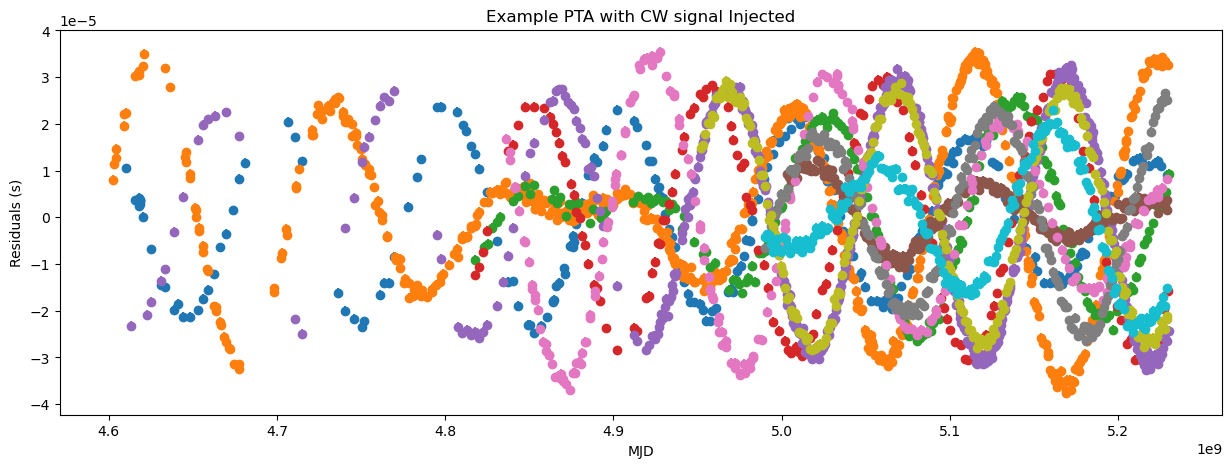

In [4]:
# Check Enterprise simulated residuals
plt.figure(figsize=(15,5))
for i, res_i in enumerate(sim_resids):
    plt.errorbar(e_psrs[i].toas, res_i, yerr=e_psrs[i].toaerrs, fmt='o')
    plt.xlabel('MJD')   
    plt.ylabel('Residuals (s)')
    plt.title("Example PTA with CW signal Injected")

In [5]:

# Discovery side: build log-likelihood with the simulated residuals
d_psrs = load_discovery_pulsars(cfg)
residual_map = {psr.name: name_to_resid[psr.name] for psr in d_psrs}
logl, param_keys = build_discovery_loglike(d_psrs, cw_draws, cfg, ring_vecs=ring_vecs, residual_map=residual_map)
logpost = make_logposterior(logl)


W1203 14:16:16.866802  358607 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1203 14:16:16.868410  358378 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


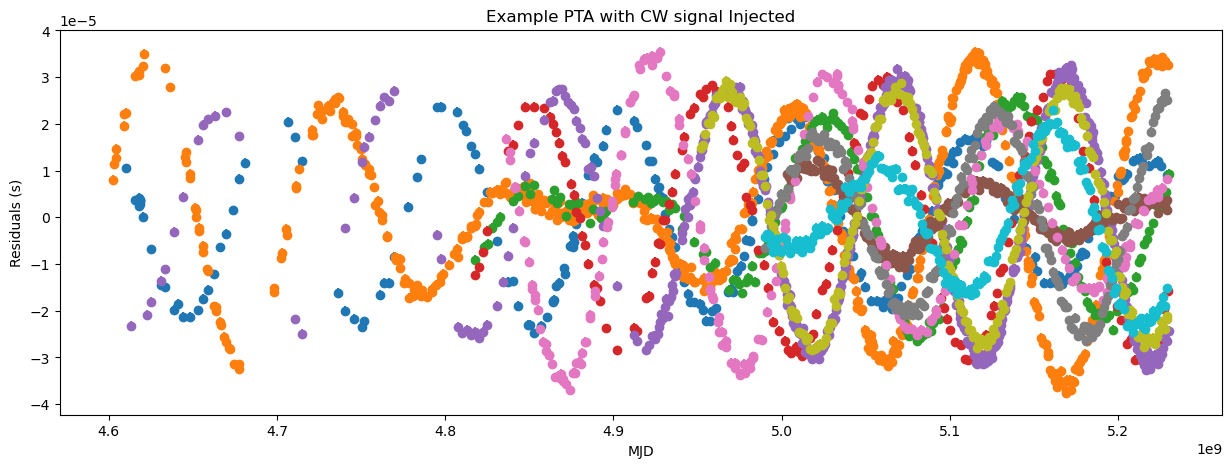

In [6]:
plt.figure(figsize=(15,5))
for i, res_i in enumerate(sim_resids):
    plt.errorbar(d_psrs[i].toas, d_psrs[i].residuals, yerr=d_psrs[i].toaerrs, fmt='o')
    plt.xlabel('MJD')   
    plt.ylabel('Residuals (s)')
    plt.title("Example PTA with CW signal Injected")

In [18]:
# Initialise from injected parameters (fallback to zero if missing)
init_params = {k: inj_params.get(k, 0.0) for k in param_keys}
if opt_mode == "svi":
    result = run_svi_map(
        logpost,
        param_keys,
        init_params,
        batch_size=1000,
        max_batches=50,
        patience=3,
        peak_lr=5e-4,
        gradient_clipping_val=0.5,
        rng_seed=seed,
    )
else:
    result = run_map_gradient_ascent(
        logpost,
        param_keys,
        init_params,
        learning_rate=learning_rate,
        max_steps=steps,
    )
print(f"Finished MAP run. converged={result.converged} grad_norm={result.grad_norm:.3e}")
if result.trace:
    print(f"logpost trace (first/last): {result.trace[0]:.3f} -> {result.trace[-1]:.3f}")
# Show a small subset of parameters for quick inspection
for key in param_keys[: min(10, len(param_keys))]:
    val = result.params[key]
    inj = inj_params.get(key, None)
    delta = None if inj is None else val - inj
    if delta is None:
        print(f"{key:>24}: {val:.4f}")
    else:
        print(f"{key:>24}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})")

# Optional: refine with L-BFGS (jaxopt) starting from SVI/MAP result
try:
    import jaxopt
    lbfgs = jaxopt.LBFGS(fun=lambda x: -logpost(x, param_keys), maxiter=50, linesearch="backtracking")
    x0 = jnp.array([result.params.get(k, init_params.get(k, 0.0)) for k in param_keys])
    sol = lbfgs.run(x0)
    x_opt = sol.params
    refined = {k: float(v) for k, v in zip(param_keys, x_opt)}
    print("\nL-BFGS refinement (50 iters):")
    for key in param_keys[: min(10, len(param_keys))]:
        val = refined[key]
        inj = inj_params.get(key, None)
        delta = None if inj is None else val - inj
        if delta is None:
            print(f"{key:>24}: {val:.4f}")
        else:
            print(f"{key:>24}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})")
except ImportError:
    print("jaxopt not installed; skipping LBFGS refinement.")


Finished MAP run. converged=True grad_norm=nan
      B1855+09_cw_p_dist: 1.0783 (inj 1.1800, delta -1.02e-01)
      B1937+21_cw_p_dist: 4.3387 (inj 3.1000, delta +1.24e+00)
      B1953+29_cw_p_dist: 5.8820 (inj 4.6400, delta +1.24e+00)
    J0023+0923_cw_p_dist: 0.7630 (inj 1.0200, delta -2.57e-01)
    J0030+0451_cw_p_dist: 0.2466 (inj 0.3296, delta -8.30e-02)
    J0125-2327_cw_p_dist: 0.6269 (inj 0.8730, delta -2.46e-01)
    J0340+4130_cw_p_dist: 1.8630 (inj 1.7100, delta +1.53e-01)
    J0406+3039_cw_p_dist: 1.5112 (inj 1.7200, delta -2.09e-01)
    J0437-4715_cw_p_dist: 0.2681 (inj 0.1549, delta +1.13e-01)
    J0509+0856_cw_p_dist: 0.9624 (inj 1.4500, delta -4.88e-01)

L-BFGS refinement (50 iters):
      B1855+09_cw_p_dist: 23.3986 (inj 1.1800, delta +2.22e+01)
      B1937+21_cw_p_dist: 110.0726 (inj 3.1000, delta +1.07e+02)
      B1953+29_cw_p_dist: 150.8235 (inj 4.6400, delta +1.46e+02)
    J0023+0923_cw_p_dist: 57.7483 (inj 1.0200, delta +5.67e+01)
    J0030+0451_cw_p_dist: 69.0839 

In [19]:
for key in param_keys:
    val = result.params[key]
    inj = inj_params.get(key, None)
    delta = None if inj is None else val - inj
    if delta is None:
        print(f"{key:>24}: {val:.4f}")
    else:
        print(f"{key:>24}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})")

      B1855+09_cw_p_dist: 1.0783 (inj 1.1800, delta -1.02e-01)
      B1937+21_cw_p_dist: 4.3387 (inj 3.1000, delta +1.24e+00)
      B1953+29_cw_p_dist: 5.8820 (inj 4.6400, delta +1.24e+00)
    J0023+0923_cw_p_dist: 0.7630 (inj 1.0200, delta -2.57e-01)
    J0030+0451_cw_p_dist: 0.2466 (inj 0.3296, delta -8.30e-02)
    J0125-2327_cw_p_dist: 0.6269 (inj 0.8730, delta -2.46e-01)
    J0340+4130_cw_p_dist: 1.8630 (inj 1.7100, delta +1.53e-01)
    J0406+3039_cw_p_dist: 1.5112 (inj 1.7200, delta -2.09e-01)
    J0437-4715_cw_p_dist: 0.2681 (inj 0.1549, delta +1.13e-01)
    J0509+0856_cw_p_dist: 0.9624 (inj 1.4500, delta -4.88e-01)
          cw_cos_gwtheta: 0.6504 (inj -0.6482, delta +1.30e+00)
              cw_cos_inc: 0.0746 (inj 0.3647, delta -2.90e-01)
                cw_gwphi: 0.2178 (inj 1.1584, delta -9.41e-01)
            cw_log10_fgw: -9.1702 (inj -8.0000, delta -1.17e+00)
              cw_log10_h: -12.7600 (inj -12.0000, delta -7.60e-01)
             cw_log10_mc: 8.1000 (inj 10.0000, d

In [20]:
inj_params

{'gwb_gamma': 4.333,
 'gwb_log10_A': -18.5,
 'B1855+09_cw_p_dist': 1.18,
 'B1937+21_cw_p_dist': 3.1,
 'B1953+29_cw_p_dist': 4.64,
 'J0023+0923_cw_p_dist': 1.02,
 'J0030+0451_cw_p_dist': 0.3296,
 'J0125-2327_cw_p_dist': 0.873,
 'J0340+4130_cw_p_dist': 1.71,
 'J0406+3039_cw_p_dist': 1.72,
 'J0437-4715_cw_p_dist': 0.1549,
 'J0509+0856_cw_p_dist': 1.45,
 'cw_cos_inc': 0.3647037264962869,
 'cw_log10_fgw': -8.0,
 'cw_log10_h': -12.0,
 'cw_log10_mc': 10.0,
 'cw_gwphi': 1.1584422520399775,
 'cw_cos_gwtheta': -0.6481881978299393,
 'cw_phase0': 0.33816743455556175,
 'cw_psi': 0.6922809574484173}

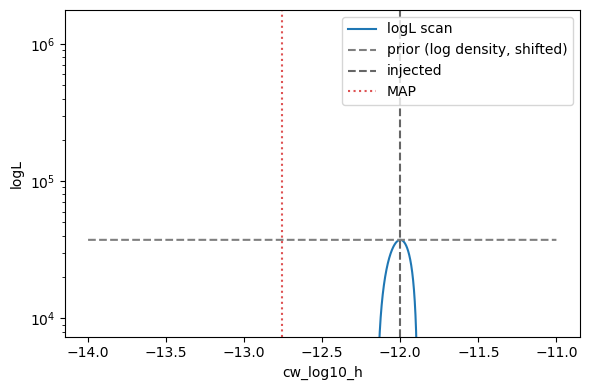

In [21]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import numpyro.distributions as dist

psr_prior_map = {p.name: (float(p.pdist[0]), float(p.pdist[1])) for p in e_psrs}

def scan_param_with_prior(param_name, scan_values, base_params=None):
    # Scan a single parameter; overlay injected, MAP, and prior logpdf (shifted).
    if base_params is None:
        base_params = inj_params
    if param_name not in param_keys:
        raise ValueError(f'{param_name} not in param_keys')
    idx = param_keys.index(param_name)
    template = jnp.array([base_params.get(k, 0.0) for k in param_keys])

    @jax.jit
    def eval_point(val):
        x = template.at[idx].set(val)
        return logpost(x, param_keys)

    batched = jax.jit(jax.vmap(eval_point))
    vals = jnp.array(scan_values)
    logls = np.array(batched(vals))

    if param_name.endswith('_cw_p_dist'):
        psr_name = param_name.replace('_cw_p_dist', '')
        mean, sigma = psr_prior_map.get(psr_name, (float(base_params.get(param_name, 1.0)), 1.0))
        sigma = max(sigma, 1e-3)
        prior = dist.Normal(loc=mean, scale=sigma)
    else:
        init_val = float(base_params.get(param_name, 0.0))
        prior = dist.Normal(loc=init_val, scale=5.0)
    prior_lp = np.array(prior.log_prob(vals))
    prior_lp = prior_lp - prior_lp.max() + logls.max()

    plt.figure(figsize=(6, 4))
    plt.plot(vals, logls, label='logL scan')
    plt.plot(vals, prior_lp, ls='--', color='tab:gray', label='prior (log density, shifted)')
    if param_name in inj_params:
        plt.axvline(inj_params[param_name], color='k', ls='--', alpha=0.6, label='injected')
    if param_name in result.params:
        plt.axvline(result.params[param_name], color='tab:red', ls=':', alpha=0.8, label='MAP')
    plt.xlabel(param_name)
    plt.ylabel('logL')
    plt.ylim(bottom=logls.max() - 30000)
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage: set parameter and range
scan_param_name = 'cw_log10_h'  # e.g., 'cw_log10_h' or 'B1855+09_cw_p_dist'
scan_range = np.linspace(-14, -11, 10000)
scan_param_with_prior(scan_param_name, scan_range)


In [22]:
# Optional bounded L-BFGS-B refinement (uses prior-informed bounds to prevent drift)
try:
    import jaxopt
    import jax.numpy as jnp
except Exception as exc:
    print('jaxopt not installed; skipping LBFGS-B refinement.', exc)
else:
    lower = []
    upper = []
    x0 = []
    for name in param_keys:
        val = result.params.get(name, init_params.get(name, 0.0))
        x0.append(val)
        if name.endswith('_cw_p_dist'):
            psr_name = name.replace('_cw_p_dist', '')
            mu, sigma = psr_prior_map.get(psr_name, (val, 10.0))
            lb = max(1e-3, mu - 5.0 * sigma)
            ub = mu + 5.0 * sigma
        elif name == 'cw_log10_h':
            lb, ub = -16.0, -8.0
        else:
            lb, ub = -np.inf, np.inf
        lower.append(lb)
        upper.append(ub)

    lbfgsb = jaxopt.LBFGSB(fun=lambda x: -logpost(x, param_keys), maxiter=100, tol=1e-4)
    sol = lbfgsb.run(jnp.array(x0), bounds=(jnp.array(lower), jnp.array(upper)))
    lbfgsb_params = {k: float(v) for k, v in zip(param_keys, sol.params)}
    result.params.update(lbfgsb_params)

    print('L-BFGS-B refinement (bounded to 5σ around priors for distances):')
    for key in param_keys[: min(10, len(param_keys))]:
        val = lbfgsb_params[key]
        inj = inj_params.get(key, None)
        delta = None if inj is None else val - inj
        if delta is None:
            print(f'  {key}: {val:.4f}')
        else:
            print(f'  {key}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})')


L-BFGS-B refinement (bounded to 5σ around priors for distances):
  B1855+09_cw_p_dist: 1.3144 (inj 1.1800, delta +1.34e-01)
  B1937+21_cw_p_dist: 4.3386 (inj 3.1000, delta +1.24e+00)
  B1953+29_cw_p_dist: 5.7216 (inj 4.6400, delta +1.08e+00)
  J0023+0923_cw_p_dist: 1.1810 (inj 1.0200, delta +1.61e-01)
  J0030+0451_cw_p_dist: 0.2441 (inj 0.3296, delta -8.55e-02)
  J0125-2327_cw_p_dist: 1.0628 (inj 0.8730, delta +1.90e-01)
  J0340+4130_cw_p_dist: 3.1149 (inj 1.7100, delta +1.40e+00)
  J0406+3039_cw_p_dist: 3.5691 (inj 1.7200, delta +1.85e+00)
  J0437-4715_cw_p_dist: 1.6554 (inj 0.1549, delta +1.50e+00)
  J0509+0856_cw_p_dist: 0.8939 (inj 1.4500, delta -5.56e-01)


In [23]:
# Multi-start bounded LBFGS-B refinement with jitter around current MAP
try:
    import jaxopt
    import jax.numpy as jnp
    import numpy as np
except Exception as exc:
    print('jaxopt not installed; skipping multi-start refinement.', exc)
else:
    def build_bounds():
        lower, upper = [], []
        for name in param_keys:
            if name.endswith('_cw_p_dist'):
                psr_name = name.replace('_cw_p_dist', '')
                mu, sigma = psr_prior_map.get(psr_name, (result.params.get(name, 1.0), 10.0))
                lb = max(1e-3, mu - 5.0 * sigma)
                ub = mu + 5.0 * sigma
            elif name == 'cw_log10_h':
                lb, ub = -16.0, -8.0
            else:
                lb, ub = -np.inf, np.inf
            lower.append(lb)
            upper.append(ub)
        return jnp.array(lower), jnp.array(upper)

    def run_lbfgsb(x0, bounds):
        opt = jaxopt.LBFGSB(fun=lambda x: -logpost(x, param_keys), maxiter=200, tol=1e-5)
        return opt.run(jnp.array(x0), bounds=bounds)

    rng = np.random.default_rng(seed + 1)
    lower, upper = build_bounds()
    base = jnp.array([result.params.get(k, init_params.get(k, 0.0)) for k in param_keys])
    best_params = None
    best_val = np.inf
    n_starts = 5
    jitter_scale = 0.1  # 10% relative jitter on free params

    for i in range(n_starts):
        noise = rng.normal(scale=jitter_scale, size=base.shape)
        x0 = base * (1.0 + noise)
        x0 = jnp.clip(x0, lower, upper)
        sol = run_lbfgsb(x0, (lower, upper))
        val = float(sol.state.value)
        if val < best_val:
            best_val = val
            best_params = sol.params
    if best_params is not None:
        result.params.update({k: float(v) for k, v in zip(param_keys, best_params)})
        print(f'Multi-start LBFGS-B: best neglogpost {best_val:.3f}')
        for key in param_keys[: min(10, len(param_keys))]:
            val = result.params[key]
            inj = inj_params.get(key, None)
            delta = None if inj is None else val - inj
            if delta is None:
                print(f'  {key}: {val:.4f}')
            else:
                print(f'  {key}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})')


Multi-start LBFGS-B: best neglogpost 355323.731
  B1855+09_cw_p_dist: 1.1781 (inj 1.1800, delta -1.87e-03)
  B1937+21_cw_p_dist: 3.9124 (inj 3.1000, delta +8.12e-01)
  B1953+29_cw_p_dist: 5.2513 (inj 4.6400, delta +6.11e-01)
  J0023+0923_cw_p_dist: 1.0706 (inj 1.0200, delta +5.06e-02)
  J0030+0451_cw_p_dist: 0.3208 (inj 0.3296, delta -8.83e-03)
  J0125-2327_cw_p_dist: 1.0368 (inj 0.8730, delta +1.64e-01)
  J0340+4130_cw_p_dist: 3.2196 (inj 1.7100, delta +1.51e+00)
  J0406+3039_cw_p_dist: 3.3514 (inj 1.7200, delta +1.63e+00)
  J0437-4715_cw_p_dist: 0.1595 (inj 0.1549, delta +4.57e-03)
  J0509+0856_cw_p_dist: 1.0409 (inj 1.4500, delta -4.09e-01)


In [25]:
print(f'Multi-start LBFGS-B: best neglogpost {best_val:.3f}')
for key in param_keys:
    val = result.params[key]
    inj = inj_params.get(key, None)
    delta = None if inj is None else val - inj
    if delta is None:
        print(f'  {key}: {val:.4f}')
    else:
        print(f'  {key}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})')

Multi-start LBFGS-B: best neglogpost 355323.731
  B1855+09_cw_p_dist: 1.1781 (inj 1.1800, delta -1.87e-03)
  B1937+21_cw_p_dist: 3.9124 (inj 3.1000, delta +8.12e-01)
  B1953+29_cw_p_dist: 5.2513 (inj 4.6400, delta +6.11e-01)
  J0023+0923_cw_p_dist: 1.0706 (inj 1.0200, delta +5.06e-02)
  J0030+0451_cw_p_dist: 0.3208 (inj 0.3296, delta -8.83e-03)
  J0125-2327_cw_p_dist: 1.0368 (inj 0.8730, delta +1.64e-01)
  J0340+4130_cw_p_dist: 3.2196 (inj 1.7100, delta +1.51e+00)
  J0406+3039_cw_p_dist: 3.3514 (inj 1.7200, delta +1.63e+00)
  J0437-4715_cw_p_dist: 0.1595 (inj 0.1549, delta +4.57e-03)
  J0509+0856_cw_p_dist: 1.0409 (inj 1.4500, delta -4.09e-01)
  cw_cos_gwtheta: -0.3484 (inj -0.6482, delta +3.00e-01)
  cw_cos_inc: 0.1120 (inj 0.3647, delta -2.53e-01)
  cw_gwphi: -0.7350 (inj 1.1584, delta -1.89e+00)
  cw_log10_fgw: -8.0197 (inj -8.0000, delta -1.97e-02)
  cw_log10_h: -12.7581 (inj -12.0000, delta -7.58e-01)
  cw_log10_mc: 9.1883 (inj 10.0000, delta -8.12e-01)
  cw_phase0: -1.0140 (inj 0